# Exercício 10 — Lei dos Grandes Números: Normal vs. Cauchy

**Enunciado:** Considere duas sequências de variáveis aleatórias independentes,

$$X_1, X_2, \dots, X_n \overset{iid}{\sim} \mathcal{N}(0, 1) \qquad \text{e} \qquad Y_1, Y_2, \dots, Y_n \overset{iid}{\sim} f_Y(y), \quad f_Y(y) = \frac{1}{\pi(1+y^2)}.$$

Defina as médias amostrais

$$\overline{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i, \qquad \overline{Y}_n = \frac{1}{n}\sum_{i=1}^{n} Y_i.$$

- (a) Antes de realizar qualquer simulação, descreva qualitativamente como você espera que $\overline{X}_n$ e $\overline{Y}_n$ se comportem à medida que $n$ aumenta.
- (b) Gere uma realização de cada sequência e represente graficamente $\overline{X}_n$ e $\overline{Y}_n$ em função de $n$, para $n = 1, \dots, 10000$. Compare os comportamentos observados.
- (c) Repita o experimento muitas vezes e obtenha histogramas de $\overline{X}_n$ e $\overline{Y}_n$ para alguns valores de $n$, por exemplo, $n = 10, 100, 1000$ e $10000$. Como a dispersão dessas distribuições muda com $n$?
- (d) Para o caso normal, determine a distribuição de $\overline{X}_n$ e explique como sua dispersão depende de $n$. Para o caso de Cauchy, use o fato de que $\overline{Y}_n$ também possui distribuição de Cauchy padrão. Use essas informações para explicar as diferenças observadas nas simulações.
- (e) Para as variáveis $Y_i$, substitua a média amostral pela mediana amostral. Repita as simulações dos itens anteriores e compare o comportamento da média e da mediana à medida que o tamanho da amostra aumenta.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_max = 10_000
t_max = 1000 


## Item (a)

**Enunciado:** Antes de realizar qualquer simulação, descreva qualitativamente como você espera que $\overline{X}_n$ e $\overline{Y}_n$ se comportem à medida que $n$ aumenta.

**Solução:**

Para a sequência $X_i$, temos pela lei fraca dos Grandes números que quando maior for n, a média de $\overline{X}_n$ converge em probabilidade para à média de $X_i$ que é igual a 0, só que quando olhamos para $Y_i$ estamos falando de variáveis aleatórias que possuem um distribuição de cauda pesada, que impossibilita inferir informação sobre a média de $\overline{Y}_n$ que vai divergir uma vez que a média de $Y_i$ diverge.


## Item (b)

**Enunciado:** Gere uma realização de cada sequência e represente graficamente $\overline{X}_n$ e $\overline{Y}_n$ em função de $n$, para $n = 1, \dots, 10000$. Compare os comportamentos observados.


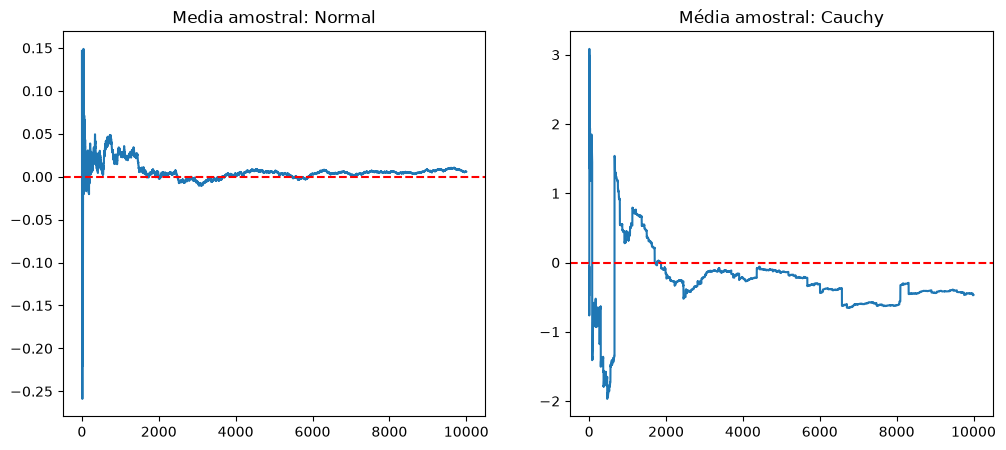

In [29]:

x = rng.normal(0, 1, n_max)
y = rng.standard_cauchy(size=n_max)

n = np.arange(1, n_max + 1)
media_x = np.cumsum(x) / n
media_y = np.cumsum(y) / n

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].plot(n, media_x)
ax[0].axhline(0, color='r', linestyle='--')
ax[0].set_title('Media amostral: Normal')

ax[1].plot(n, media_y)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_title('Média amostral: Cauchy')

plt.show()

## Item (c)

**Enunciado:** Repita o experimento muitas vezes e obtenha histogramas de $\overline{X}_n$ e $\overline{Y}_n$ para alguns valores de $n$, por exemplo, $n = 10, 100, 1000$ e $10000$. Como a dispersão dessas distribuições muda com $n$?


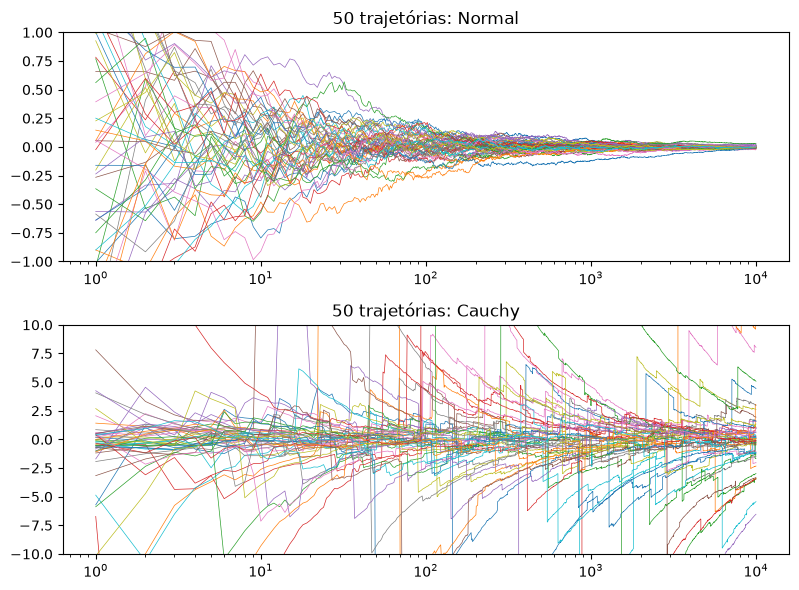

In [11]:
X = rng.normal(0, 1, size=(t_max, n_max))
Y = rng.standard_cauchy(size=(t_max, n_max))

n = np.arange(1, n_max + 1)

medias_x = np.cumsum(X, axis=1) / n
medias_y = np.cumsum(Y, axis=1) / n



fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i in range(50):
    ax[0].plot(n, medias_x[i], linewidth=0.5)
    ax[1].plot(n, medias_y[i], linewidth=0.5)

ax[0].set_ylim(-1, 1)
ax[1].set_ylim(-10, 10)
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[0].set_title('50 trajetórias: Normal')
ax[1].set_title('50 trajetórias: Cauchy')

plt.tight_layout()
plt.show()

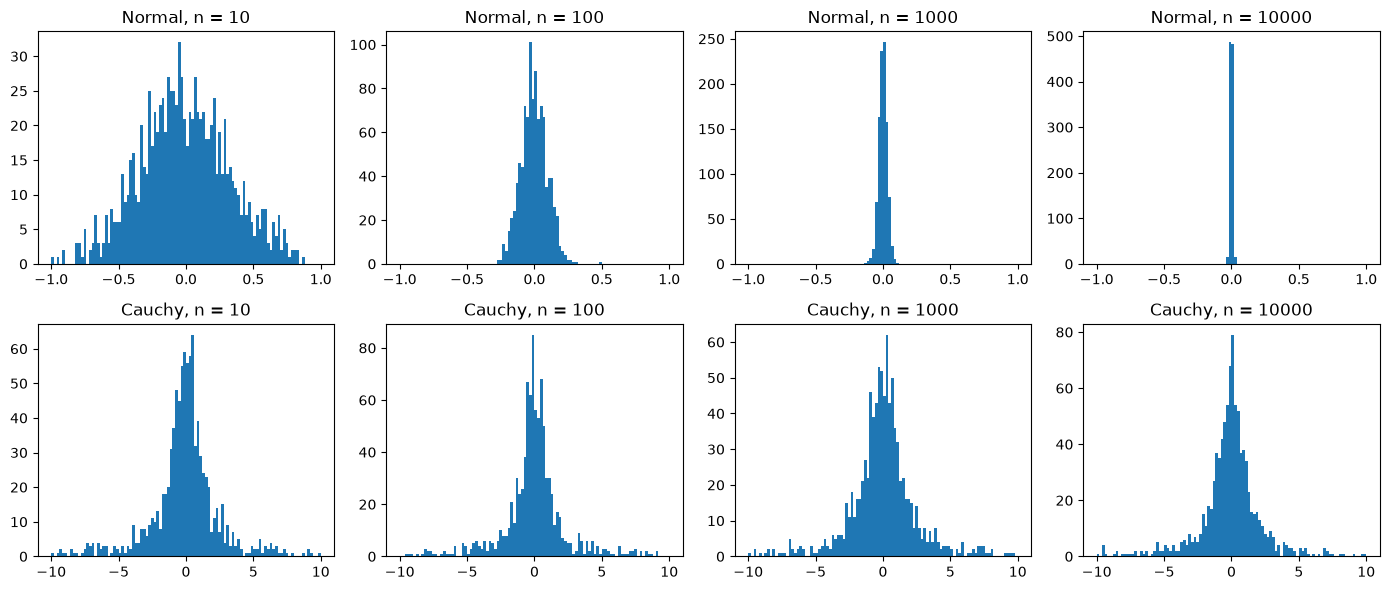

In [12]:
valores_n = [10, 100, 1000, 10000]

fig, ax = plt.subplots(2, 4, figsize=(14, 6))

for j in range(4):
    k = valores_n[j]

    ax[0, j].hist(medias_x[:, k - 1], bins=100, range=(-1, 1))
    ax[0, j].set_title(f'Normal, n = {k}')

    ax[1, j].hist(medias_y[:, k - 1], bins=100, range=(-10, 10))
    ax[1, j].set_title(f'Cauchy, n = {k}')

plt.tight_layout()
plt.show()

## Item (d)

**Enunciado:** Para o caso normal, determine a distribuição de $\overline{X}_n$ e explique como sua dispersão depende de $n$. Para o caso de Cauchy, use o seguinte fato: se $Y_1, \dots, Y_n$ são independentes e possuem distribuição de Cauchy padrão, então $\overline{Y}_n$ também possui distribuição de Cauchy padrão. Use essas informações para explicar as diferenças observadas nas simulações.

**Solução:**

Para $\overline{X}_n$: como os $X_i$ são iid $N(0,1)$, a soma de normais independentes é normal, então
$\overline{X}_n \sim N(0, 1/n)$. Ou seja, o desvio padrão de $\overline{X}_n$ cai como $1/\sqrt{n}$,
e é por isso que os histogramas do item (c) vão ficando mais estreitos e concentrados em 0 conforme $n$ cresce.

Para $\overline{Y}_n$: pelo fato dado no enunciado, a média de Cauchy padrão iid continua sendo Cauchy
padrão para qualquer $n$. Então $\overline{Y}_n$ não converge (nem em distribuição, nem em probabilidade)
para 0 — o histograma de $\overline{Y}_n$ deveria ficar parecido para todo $n$, sem estreitar. Isso faz
sentido pois a Cauchy não tem média nem variância finita, então a LGN (que precisa de média finita) não se
aplica.

Abaixo eu confiro isso numericamente: comparo o desvio padrão amostral de $\overline{X}_n$ com o valor
teórico $1/\sqrt{n}$, e olho o IQR (interquartile range) de $\overline{Y}_n$ já que desvio padrão não faz
sentido pra Cauchy.


In [13]:
print("X_n: desvio padrao empirico vs. teorico (1/sqrt(n))")
for k in valores_n:
    dp_emp = medias_x[:, k - 1].std()
    dp_teo = 1 / np.sqrt(k)
    print(f"n = {k:5d}   empirico = {dp_emp:.4f}   teorico = {dp_teo:.4f}")

print()
print("Y_n: IQR amostral (deveria ficar ~constante, pois Y_n ~ Cauchy(0,1) para qualquer n)")
for k in valores_n:
    q25, q75 = np.percentile(medias_y[:, k - 1], [25, 75])
    print(f"n = {k:5d}   IQR = {q75 - q25:.4f}")


X_n: desvio padrao empirico vs. teorico (1/sqrt(n))
n =    10   empirico = 0.3318   teorico = 0.3162
n =   100   empirico = 0.0970   teorico = 0.1000
n =  1000   empirico = 0.0316   teorico = 0.0316
n = 10000   empirico = 0.0097   teorico = 0.0100

Y_n: IQR amostral (deveria ficar ~constante, pois Y_n ~ Cauchy(0,1) para qualquer n)
n =    10   IQR = 2.0342
n =   100   IQR = 1.7760
n =  1000   IQR = 2.2507
n = 10000   IQR = 1.9688


## Item (e)

**Enunciado:** Para as variáveis $Y_i$, substitua a média amostral pela mediana amostral. Repita as simulações dos itens anteriores e compare o comportamento da média e da mediana à medida que o tamanho da amostra aumenta.

**Solução:**

A média amostral de Cauchy não converge, mas a mediana amostral converge (a mediana da Cauchy(0,1) é 0, e
diferente da média, a mediana não depende dos momentos da distribuição, só precisa que a densidade seja
"bem comportada" perto do ponto). Vou refazer os itens (b) e (c) trocando a média pela mediana nos $Y_i$.

Obs: calcular a mediana em cada $n$ não dá pra fazer com `cumsum` (não é uma função aditiva), então para a
trajetória eu só calculo em alguns pontos de $n$ espaçados em escala log, senão fica muito lento.


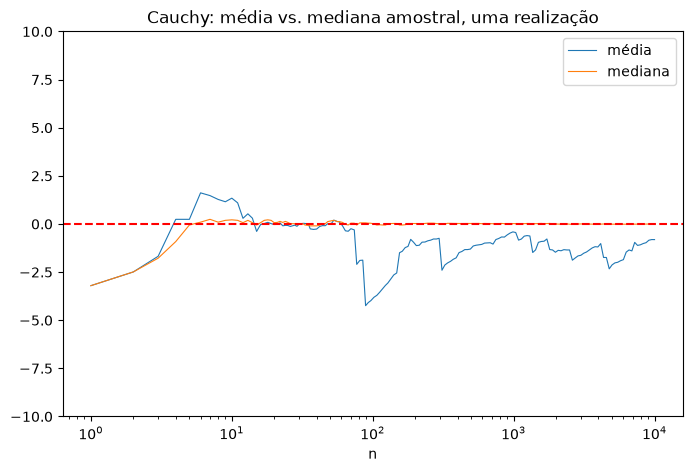

In [14]:
n_med = np.unique(np.logspace(0, np.log10(n_max), 200).astype(int))

y_real = rng.standard_cauchy(size=n_max)
n_full = np.arange(1, n_max + 1)
media_y_real = np.cumsum(y_real) / n_full
mediana_y_real = np.array([np.median(y_real[:k]) for k in n_med])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_med, media_y_real[n_med - 1], label='média', linewidth=0.8)
ax.plot(n_med, mediana_y_real, label='mediana', linewidth=0.8)
ax.axhline(0, color='r', linestyle='--')
ax.set_xscale('log')
ax.set_ylim(-10, 10)
ax.set_xlabel('n')
ax.legend()
ax.set_title('Cauchy: média vs. mediana amostral, uma realização')

plt.show()


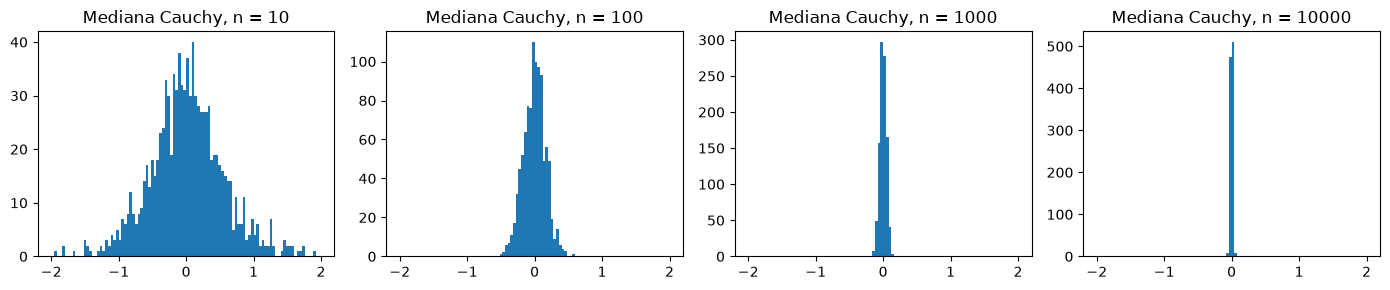

Desvio padrao amostral da mediana de Y_n:
n =    10   dp = 0.6084
n =   100   dp = 0.1627
n =  1000   dp = 0.0492
n = 10000   dp = 0.0159


In [15]:
Y_med = rng.standard_cauchy(size=(t_max, n_max))

medianas = np.zeros((t_max, len(valores_n)))
for j, k in enumerate(valores_n):
    medianas[:, j] = np.median(Y_med[:, :k], axis=1)

fig, ax = plt.subplots(1, 4, figsize=(14, 3))
for j, k in enumerate(valores_n):
    ax[j].hist(medianas[:, j], bins=100, range=(-2, 2))
    ax[j].set_title(f'Mediana Cauchy, n = {k}')

plt.tight_layout()
plt.show()

print("Desvio padrao amostral da mediana de Y_n:")
for j, k in enumerate(valores_n):
    print(f"n = {k:5d}   dp = {medianas[:, j].std():.4f}")


## Conclusão

- Pra $X_n$ (Normal) tanto a trajetória quanto os histogramas mostram convergência clara: $\overline{X}_n \to 0$
  e a dispersão cai com $1/\sqrt{n}$, como esperado pela LGN + o fato de $\overline{X}_n \sim N(0, 1/n)$.
- Pra $\overline{Y}_n$ (Cauchy) a média amostral **não** converge: a trajetória continua "saltando" mesmo
  com $n$ grande, e os histogramas não ficam mais estreitos, porque $\overline{Y}_n$ é sempre Cauchy(0,1) —
  a LGN não vale aqui porque a Cauchy não tem média finita.
- Trocando a média pela mediana em $Y_i$, o comportamento muda bastante: a mediana amostral converge pra 0
  e o desvio padrão dela cai com $n$ (mesmo a Cauchy não tendo variância finita), porque a mediana é um
  estimador que não depende dos momentos da distribuição. Isso mostra na prática por que a mediana é
  considerada um estimador mais robusto que a média quando lidamos com distribuições de cauda pesada.